# Step 4 (v3) — Next-Day Direction Prediction: Extended Data + Walk-Forward Validation


## 1. Imports


In [1]:
# %pip install scikit-learn joblib xgboost

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

print("XGBoost available:", HAS_XGBOOST)


XGBoost available: True


## 2. Configuration


In [2]:
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

PROCESSED_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_FRACTION = 0.2
RANDOM_STATE = 42
CONFIDENCE_THRESHOLD = 0.60   # only act on predictions with max class probability above this

print("Processed data directory:", PROCESSED_DIR.resolve())
print("Model output directory:", OUTPUT_DIR.resolve())


Processed data directory: D:\Projects\stock-market-prediction\data\processed
Model output directory: D:\Projects\stock-market-prediction\data\models


## 3. Load the Final Combined Dataset (Step 3)


In [3]:
data = pd.read_parquet(PROCESSED_DIR / "final_combined_dataset.parquet")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Loaded shape:", data.shape)


Loaded shape: (3016, 12)


## 4. Feature Engineering: Returns, Target, and Technical Indicators


In [4]:
def add_indicators(group):
    group = group.sort_values("Date").copy()

    group["Return"] = group["Close"].pct_change()

    group["SMA_5"] = group["Close"].rolling(5, min_periods=1).mean()
    group["SMA_10"] = group["Close"].rolling(10, min_periods=1).mean()
    group["EMA_5"] = group["Close"].ewm(span=5, adjust=False).mean()
    group["EMA_10"] = group["Close"].ewm(span=10, adjust=False).mean()
    group["Price_to_SMA10"] = group["Close"] / group["SMA_10"] - 1

    delta = group["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    group["RSI_14"] = (100 - (100 / (1 + rs))).fillna(50.0)

    ema_12 = group["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = group["Close"].ewm(span=26, adjust=False).mean()
    group["MACD"] = ema_12 - ema_26
    group["MACD_Signal"] = group["MACD"].ewm(span=9, adjust=False).mean()
    group["MACD_Hist"] = group["MACD"] - group["MACD_Signal"]

    group["Volatility_5"] = group["Return"].rolling(5, min_periods=1).std().fillna(0.0)
    group["Momentum_5"] = group["Close"] - group["Close"].shift(5)
    group["Momentum_5"] = group["Momentum_5"].fillna(0.0)
    group["Volume_Change"] = group["Volume"].pct_change()

    next_close = group["Close"].shift(-1)
    group["Direction"] = (next_close > group["Close"]).astype("float")
    group.loc[next_close.isna(), "Direction"] = np.nan

    return group

# Looping explicitly (rather than groupby().apply()) avoids a pandas-version-dependent quirk:
# pandas 3.0 changed apply() to drop the grouping column from the result by default.
frames = []
for ticker in TICKERS:
    group = data[data["Ticker"] == ticker].copy()
    group = add_indicators(group)
    frames.append(group)

data = pd.concat(frames, ignore_index=True)

before = len(data)
data = data.dropna(subset=["Return", "Volume_Change", "Direction"]).reset_index(drop=True)
after = len(data)
data["Direction"] = data["Direction"].astype(int)

print(f"Rows before dropping edge days: {before}")
print(f"Rows after dropping edge days:  {after}")
print("\nClass balance (Direction):")
print(data["Direction"].value_counts(normalize=True).round(3))


Rows before dropping edge days: 3016
Rows after dropping edge days:  3008

Class balance (Direction):
Direction
1    0.519
0    0.481
Name: proportion, dtype: float64


## 5. Chronological Train/Test Split (Per Ticker, Then Pooled)


In [5]:
train_frames, test_frames = [], []

for ticker in TICKERS:
    ticker_data = data[data["Ticker"] == ticker].sort_values("Date")
    n_test = max(1, int(round(len(ticker_data) * TEST_FRACTION)))
    train_frames.append(ticker_data.iloc[:-n_test])
    test_frames.append(ticker_data.iloc[-n_test:])

train_df = pd.concat(train_frames).sort_values("Date").reset_index(drop=True)
test_df = pd.concat(test_frames).sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Train shape:", train_df.shape, " | Test shape:", test_df.shape)


Train shape: (2408, 26)  | Test shape: (600, 26)


## 6. Build Feature Matrix


In [6]:
NUMERIC_FEATURES = [
    "Open", "High", "Low", "Close", "Adj_Close", "Volume", "Return",
    "Sentiment_Mean", "Sentiment_Std", "Headline_Count",
    "SMA_5", "SMA_10", "EMA_5", "EMA_10", "Price_to_SMA10", "RSI_14",
    "MACD", "MACD_Signal", "MACD_Hist", "Volatility_5", "Momentum_5", "Volume_Change"
]

def build_features(df):
    X = df[NUMERIC_FEATURES].copy()
    ticker_dummies = pd.get_dummies(df["Ticker"], prefix="Ticker")
    return pd.concat([X.reset_index(drop=True), ticker_dummies.reset_index(drop=True)], axis=1)

X_train_raw = build_features(train_df)
X_test_raw = build_features(test_df).reindex(columns=X_train_raw.columns, fill_value=0)

y_train = train_df["Direction"].values
y_test = test_df["Direction"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw[NUMERIC_FEATURES])
X_test_scaled = scaler.transform(X_test_raw[NUMERIC_FEATURES])

X_train = np.concatenate([X_train_scaled, X_train_raw.drop(columns=NUMERIC_FEATURES).values], axis=1)
X_test = np.concatenate([X_test_scaled, X_test_raw.drop(columns=NUMERIC_FEATURES).values], axis=1)

feature_names = NUMERIC_FEATURES + list(X_train_raw.drop(columns=NUMERIC_FEATURES).columns)

print("Feature matrix shapes:", X_train.shape, X_test.shape)
print("Number of features:", len(feature_names))


Feature matrix shapes: (2408, 26) (600, 26)
Number of features: 26


## 7. Hyperparameter Tuning with Time-Series Cross-Validation


In [7]:
tscv = TimeSeriesSplit(n_splits=5)

param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"C": [0.01, 0.1, 1.0, 10.0], "penalty": ["l2"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 300],
            "max_depth": [3, 4, 6],
            "min_samples_leaf": [3, 5, 10]
        }
    ),
}

if HAS_XGBOOST:
    param_grids["XGBoost"] = (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.03, 0.05, 0.1],
            "subsample": [0.7, 0.9]
        }
    )
else:
    param_grids["Gradient Boosting"] = (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [100, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.03, 0.05, 0.1]
        }
    )

trained_models = {}
cv_scores = {}

for name, (estimator, grid) in param_grids.items():
    search = GridSearchCV(estimator, grid, cv=tscv, scoring="accuracy", n_jobs=-1)
    search.fit(X_train, y_train)

    trained_models[name] = search.best_estimator_
    cv_scores[name] = search.best_score_

    print(f"{name}: best CV accuracy = {search.best_score_:.3f}, best params = {search.best_params_}")


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression: best CV accuracy = 0.495, best params = {'C': 10.0, 'penalty': 'l2'}
Random Forest: best CV accuracy = 0.500, best params = {'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 300}
XGBoost: best CV accuracy = 0.512, best params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}


## 8. Evaluate on the Held-Out Test Set


In [8]:
majority_class = int(pd.Series(y_train).mode()[0])
baseline_preds = np.full_like(y_test, fill_value=majority_class)

results = [{
    "Model": "Majority-Class Baseline",
    "CV Accuracy": np.nan,
    "Test Accuracy": accuracy_score(y_test, baseline_preds),
    "Precision": precision_score(y_test, baseline_preds, zero_division=0),
    "Recall": recall_score(y_test, baseline_preds, zero_division=0),
    "F1": f1_score(y_test, baseline_preds, zero_division=0),
}]

predictions = {}
probabilities = {}

for name, clf in trained_models.items():
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)
    predictions[name] = preds
    probabilities[name] = probs

    results.append({
        "Model": name,
        "CV Accuracy": cv_scores[name],
        "Test Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df)


,CV Accuracy,Test Accuracy,Precision,Recall,F1
Model,,,,,
Majority-Class Baseline,NaN,0.547,0.547,1.000,0.707
Logistic Regression,0.495,0.515,0.559,0.530,0.545
Random Forest,0.500,0.495,0.530,0.671,0.592
XGBoost,0.512,0.475,0.524,0.430,0.472


## 9. Confusion Matrices and Classification Reports


In [9]:
for name, preds in predictions.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(confusion_matrix(y_test, preds))
    print()
    print(classification_report(y_test, preds, target_names=["Down", "Up"], zero_division=0))
    print()


Logistic Regression
[[135 137]
 [154 174]]

              precision    recall  f1-score   support

        Down       0.47      0.50      0.48       272
          Up       0.56      0.53      0.54       328

    accuracy                           0.52       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.52      0.52      0.52       600


Random Forest
[[ 77 195]
 [108 220]]

              precision    recall  f1-score   support

        Down       0.42      0.28      0.34       272
          Up       0.53      0.67      0.59       328

    accuracy                           0.49       600
   macro avg       0.47      0.48      0.46       600
weighted avg       0.48      0.49      0.48       600


XGBoost
[[144 128]
 [187 141]]

              precision    recall  f1-score   support

        Down       0.44      0.53      0.48       272
          Up       0.52      0.43      0.47       328

    accuracy                           0.47       600
   macro avg

## 10. Confidence-Thresholded Evaluation


In [10]:
confidence_results = []

for name, probs in probabilities.items():
    max_conf = probs.max(axis=1)
    confident_mask = max_conf >= CONFIDENCE_THRESHOLD

    coverage = confident_mask.mean()

    if confident_mask.sum() > 0:
        conf_accuracy = accuracy_score(y_test[confident_mask], predictions[name][confident_mask])
    else:
        conf_accuracy = np.nan

    confidence_results.append({
        "Model": name,
        "Coverage": coverage,
        "N_Confident_Days": int(confident_mask.sum()),
        "Accuracy_on_Confident_Days": conf_accuracy,
    })

confidence_df = pd.DataFrame(confidence_results).set_index("Model").round(3)
display(confidence_df)


,Coverage,N_Confident_Days,Accuracy_on_Confident_Days
Model,,,
Logistic Regression,0.022,13,0.615
Random Forest,0.127,76,0.421
XGBoost,0.362,217,0.484


## 11. Walk-Forward Validation (Robustness Check)


In [11]:
from sklearn.base import clone

WALKFORWARD_SPLITS = 5

full_df = pd.concat([train_df, test_df]).sort_values("Date").reset_index(drop=True)
X_full_raw = build_features(full_df)
y_full = full_df["Direction"].values

wf_tscv = TimeSeriesSplit(n_splits=WALKFORWARD_SPLITS)

walkforward_results = {name: [] for name in trained_models}

for fold_i, (train_idx, test_idx) in enumerate(wf_tscv.split(X_full_raw), start=1):
    fold_train_raw = X_full_raw.iloc[train_idx]
    fold_test_raw = X_full_raw.iloc[test_idx]
    fold_y_train = y_full[train_idx]
    fold_y_test = y_full[test_idx]

    # Refit scaling per fold so no fold leaks statistics from data outside its own training slice
    fold_scaler = StandardScaler()
    fold_train_scaled = fold_scaler.fit_transform(fold_train_raw[NUMERIC_FEATURES])
    fold_test_scaled = fold_scaler.transform(fold_test_raw[NUMERIC_FEATURES])

    fold_X_train = np.concatenate(
        [fold_train_scaled, fold_train_raw.drop(columns=NUMERIC_FEATURES).values], axis=1
    )
    fold_X_test = np.concatenate(
        [fold_test_scaled, fold_test_raw.drop(columns=NUMERIC_FEATURES).values], axis=1
    )

    for name, fitted_model in trained_models.items():
        fold_model = clone(fitted_model)
        fold_model.fit(fold_X_train, fold_y_train)
        fold_preds = fold_model.predict(fold_X_test)
        walkforward_results[name].append(accuracy_score(fold_y_test, fold_preds))

    print(f"Fold {fold_i}: train={len(train_idx)} rows, test={len(test_idx)} rows")

walkforward_summary = pd.DataFrame({
    name: {
        "Mean_Accuracy": np.mean(scores),
        "Std_Accuracy": np.std(scores),
        "Min_Accuracy": np.min(scores),
        "Max_Accuracy": np.max(scores),
    }
    for name, scores in walkforward_results.items()
}).T.round(3)

display(walkforward_summary)

print("\nPer-fold accuracy by model:")
for name, scores in walkforward_results.items():
    print(f"{name}: {[round(s, 3) for s in scores]}")


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fold 1: train=503 rows, test=501 rows


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fold 2: train=1004 rows, test=501 rows


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

Fold 4: train=2006 rows, test=501 rows


d:\Projects\stock-market-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fold 5: train=2507 rows, test=501 rows


,Mean_Accuracy,Std_Accuracy,Min_Accuracy,Max_Accuracy
Logistic Regression,0.501,0.023,0.463,0.527
Random Forest,0.503,0.026,0.475,0.547
XGBoost,0.513,0.024,0.483,0.553



Per-fold accuracy by model:
Logistic Regression: [0.463, 0.515, 0.487, 0.527, 0.511]
Random Forest: [0.475, 0.499, 0.481, 0.547, 0.513]
XGBoost: [0.499, 0.509, 0.483, 0.553, 0.523]


## 12. Feature Importance


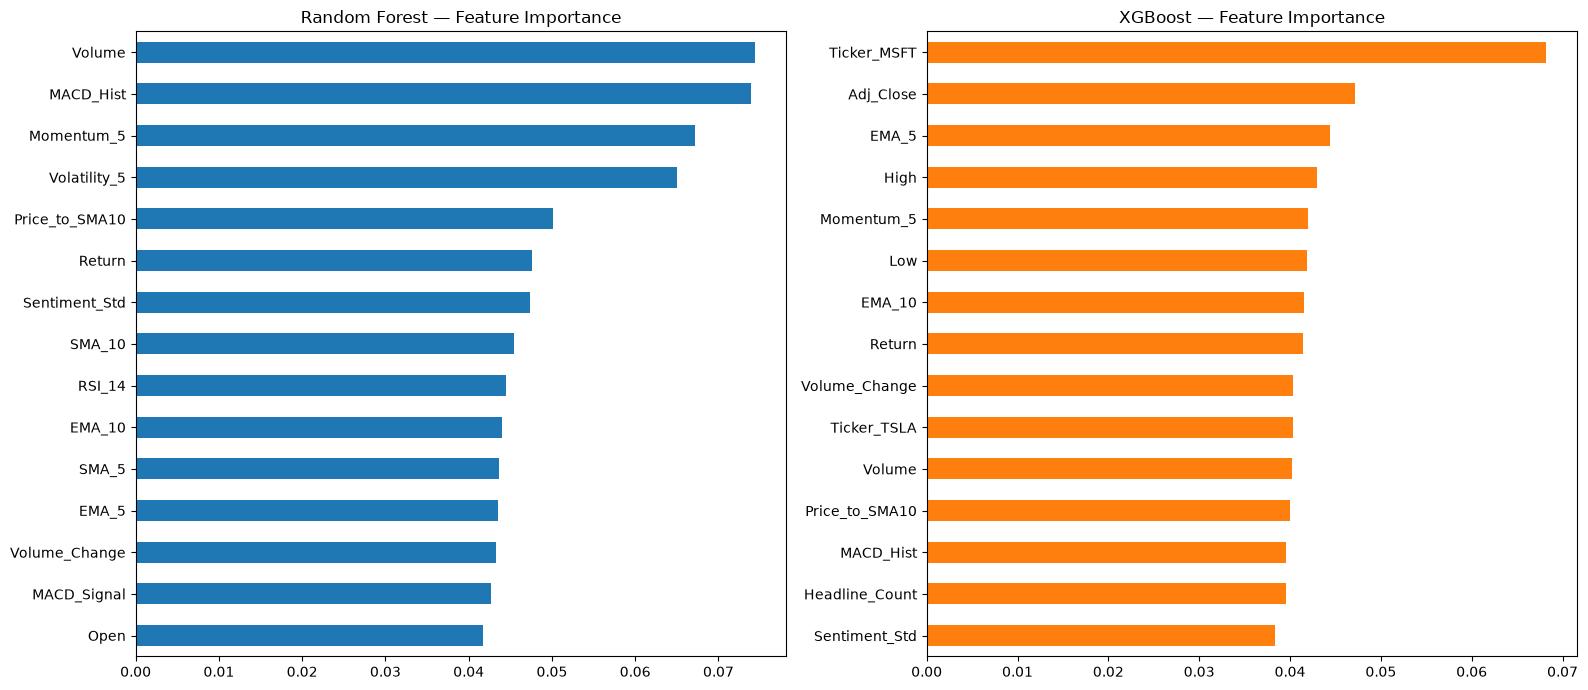

Sentiment feature importance (Random Forest):
Sentiment_Mean    0.040249
Sentiment_Std     0.047327
Headline_Count    0.022095
dtype: float64

Sentiment feature importance (XGBoost):
Sentiment_Mean    0.035430
Sentiment_Std     0.038318
Headline_Count    0.039532
dtype: float32


In [12]:
tree_model_name = "XGBoost" if HAS_XGBOOST else "Gradient Boosting"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_importances = pd.Series(
    trained_models["Random Forest"].feature_importances_, index=feature_names
).sort_values(ascending=True)
rf_importances.tail(15).plot(kind="barh", ax=axes[0], color="tab:blue")
axes[0].set_title("Random Forest — Feature Importance")

boosted_importances = pd.Series(
    trained_models[tree_model_name].feature_importances_, index=feature_names
).sort_values(ascending=True)
boosted_importances.tail(15).plot(kind="barh", ax=axes[1], color="tab:orange")
axes[1].set_title(f"{tree_model_name} — Feature Importance")

plt.tight_layout()
plt.show()

sentiment_features = ["Sentiment_Mean", "Sentiment_Std", "Headline_Count"]
print("Sentiment feature importance (Random Forest):")
print(rf_importances[sentiment_features])
print(f"\nSentiment feature importance ({tree_model_name}):")
print(boosted_importances[sentiment_features])


## 13. Save Models and Results


In [13]:
for name, clf in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(clf, OUTPUT_DIR / f"model_v3_{safe_name}.joblib")

joblib.dump(scaler, OUTPUT_DIR / "feature_scaler_v3.joblib")
joblib.dump(feature_names, OUTPUT_DIR / "feature_names_v3.joblib")

results_df.to_csv(OUTPUT_DIR / "model_comparison_results_v3.csv")
confidence_df.to_csv(OUTPUT_DIR / "confidence_threshold_results_v3.csv")

test_predictions = test_df[["Date", "Ticker", "Close", "Direction"]].copy()
for name, preds in predictions.items():
    test_predictions[f"Pred_{name.replace(' ', '_')}"] = preds
    test_predictions[f"Confidence_{name.replace(' ', '_')}"] = probabilities[name].max(axis=1)
test_predictions.to_csv(OUTPUT_DIR / "test_set_predictions_v3.csv", index=False)

print("Saved v2 models, scaler, feature list, and results to:")
print(OUTPUT_DIR.resolve())


Saved v2 models, scaler, feature list, and results to:
D:\Projects\stock-market-prediction\data\models


## 14. Final Validation


In [14]:
print("=" * 60)
print("STEP 4 (v3) VALIDATION")
print("=" * 60)

print("\nTrain rows:", len(train_df), " | Test rows:", len(test_df))
print("Number of features:", len(feature_names))

print("\nModel comparison (test set):")
display(results_df)

print("\nConfidence-thresholded results:")
display(confidence_df)

print("\nWalk-forward validation summary:")
display(walkforward_summary)

best_model = results_df.drop(index="Majority-Class Baseline")["Test Accuracy"].idxmax()
print(f"\nBest-performing model by test accuracy: {best_model}")
print("Step 4 (v3) complete.")


STEP 4 (v3) VALIDATION

Train rows: 2408  | Test rows: 600
Number of features: 26

Model comparison (test set):


,CV Accuracy,Test Accuracy,Precision,Recall,F1
Model,,,,,
Majority-Class Baseline,NaN,0.547,0.547,1.000,0.707
Logistic Regression,0.495,0.515,0.559,0.530,0.545
Random Forest,0.500,0.495,0.530,0.671,0.592
XGBoost,0.512,0.475,0.524,0.430,0.472



Confidence-thresholded results:


,Coverage,N_Confident_Days,Accuracy_on_Confident_Days
Model,,,
Logistic Regression,0.022,13,0.615
Random Forest,0.127,76,0.421
XGBoost,0.362,217,0.484



Walk-forward validation summary:


,Mean_Accuracy,Std_Accuracy,Min_Accuracy,Max_Accuracy
Logistic Regression,0.501,0.023,0.463,0.527
Random Forest,0.503,0.026,0.475,0.547
XGBoost,0.513,0.024,0.483,0.553



Best-performing model by test accuracy: Logistic Regression
Step 4 (v3) complete.


## Important Methodological Note
